<a href="https://colab.research.google.com/github/amherrera128/Analisis_de_datos/blob/main/Disminuci%C3%B3n_de_la_fidelidad_cu%C3%A1ntica_con_la_profundidad_del_circuito_bajo_ruido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentos de Información y Tecnologías Cuánticas

### Disminución de la fidelidad cuántica con la profundidad del circuito bajo ruido

In [ ]:
pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=3dd3a142db69263be7197ecbf9bb4679c327b020731437644cfbab2dbbc18dd3
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Capas:  1 | Profundidad:   6 | Fidelidad: 0.952900
Capas:  2 | Profundidad:  11 | Fidelidad: 0.910920
Capas:  3 | Profundidad:  16 | Fidelidad: 0.869389
Capas:  4 | Profundidad:  21 | Fidelidad: 0.829033
Capas:  5 | Profundidad:  26 | Fidelidad: 0.790135
Capas:  6 | Profundidad:  31 | Fidelidad: 0.753430
Capas:  7 | Profundidad:  36 | Fidelidad: 0.719136
Capas:  8 | Profundidad:  41 | Fidelidad: 0.688001
Capas:  9 | Profundidad:  46 | Fidelidad: 0.658277
Capas: 10 | Profundidad:  51 | Fidelidad: 0.629230
Capas: 11 | Profundidad:  56 | Fidelidad: 0.600601
Capas: 12 | Profundidad:  61 | Fidelidad: 0.571835
Capas: 13 | Profundidad:  66 | Fidelidad: 0.546008
Capas: 14 | Profundidad:  71 | Fidelidad: 0.522059
Capas: 15 | Profundidad:  76 | Fidelidad: 0.499056
Capas: 16 | Profundidad:  81 | Fidelidad: 0.478128
Capas: 17 | Profundidad:  86 | Fidelidad: 0.457745
Capas: 18 | Profundidad:  91 | Fidelidad: 0.438521
Capas: 19 | Profundidad:  96 | Fidelidad: 0.420160
Capas: 20 | Profundidad: 101 | 

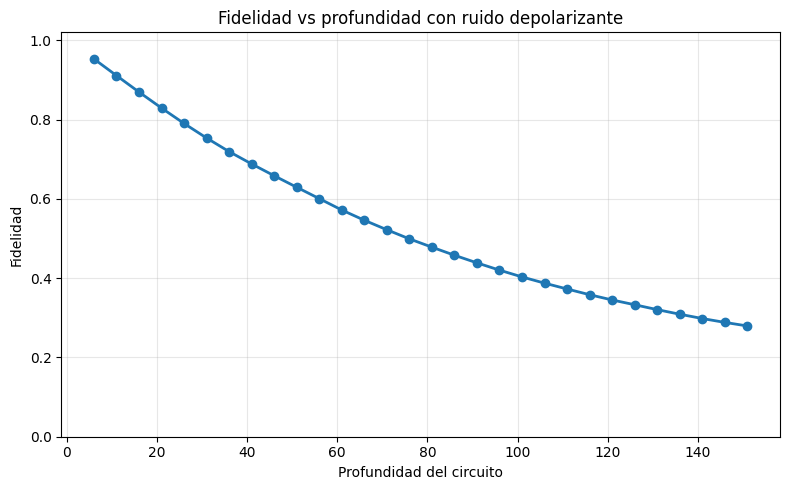

In [ ]:
# pip install qiskit qiskit-aer matplotlib

import gc #Sirve para liberar memoria que ya no se está usando.Ayuda a que no se llene la RAM
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise import depolarizing_error, amplitude_damping_error, phase_damping_error
from qiskit.quantum_info import Statevector, state_fidelity

#En ese código, las capas son repeticiones de un mismo bloque de compuertas. Cada capa aumenta la profundidad del circuito.
def crear_circuito(n_qubits, capas):
    qc = QuantumCircuit(n_qubits)

    for q in range(n_qubits):
        qc.h(q)

    for layer in range(capas):
        for q in range(n_qubits):
            qc.rx(0.17 * (layer + 1), q)
            qc.ry(0.11 * (q + 1), q)
            qc.rz(0.07 * (layer + q + 1), q)

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)

    return qc

def crear_modelo_ruido_depolarizante():
    noise_model = NoiseModel()

    error_1q = depolarizing_error(0.003, 1)
    error_2q = depolarizing_error(0.02, 2)

    for gate in ["h", "rx", "ry", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, [gate])

    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

    return noise_model


def crear_modelo_ruido_amplitude_damping():
    noise_model = NoiseModel()

    gamma_1q = 0.003
    gamma_2q = 0.02

    error_1q = amplitude_damping_error(gamma_1q)
    error_2q = amplitude_damping_error(gamma_2q).tensor(
        amplitude_damping_error(gamma_2q)
    )

    for gate in ["h", "rx", "ry", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, [gate])

    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

    return noise_model

def crear_modelo_ruido_dephasing():
    noise_model = NoiseModel()

    gamma_1q = 0.003
    gamma_2q = 0.02

    error_1q = phase_damping_error(gamma_1q)
    error_2q = phase_damping_error(gamma_2q).tensor(
        phase_damping_error(gamma_2q)
    )

    for gate in ["h", "rx", "ry", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, [gate])

    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

    return noise_model



n_qubits = 3
max_capas = 30


#noise_model = crear_modelo_ruido_amplitude_damping()
#noise_model = crear_modelo_ruido_dephasing()
noise_model = crear_modelo_ruido_depolarizante()

sim_ruidoso = AerSimulator(
    method="density_matrix",
    noise_model=noise_model
)

profundidades = []
fidelidades = []

for capas in range(1, max_capas + 1):
    qc = crear_circuito(n_qubits, capas)

    # Evolución ideal
    estado_ideal = Statevector.from_instruction(qc)

    # Evolución con ruido
    qc_noise = qc.copy()
    qc_noise.save_density_matrix()

    result = sim_ruidoso.run(qc_noise).result()
    rho_ruidoso = result.data(0)["density_matrix"]

    fidelidad = state_fidelity(estado_ideal, rho_ruidoso)

    profundidades.append(qc.depth())
    fidelidades.append(fidelidad)

    print(
        f"Capas: {capas:2d} | "
        f"Profundidad: {qc.depth():3d} | "
        f"Fidelidad: {fidelidad:.6f}"
    )

    del  qc_noise, result, rho_ruidoso, estado_ideal
    gc.collect()


plt.figure(figsize=(8, 5))
plt.plot(profundidades, fidelidades, "o-", linewidth=2)
plt.xlabel("Profundidad del circuito")
plt.ylabel("Fidelidad")
plt.title("Fidelidad vs profundidad con ruido depolarizante")
plt.grid(alpha=0.3)
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

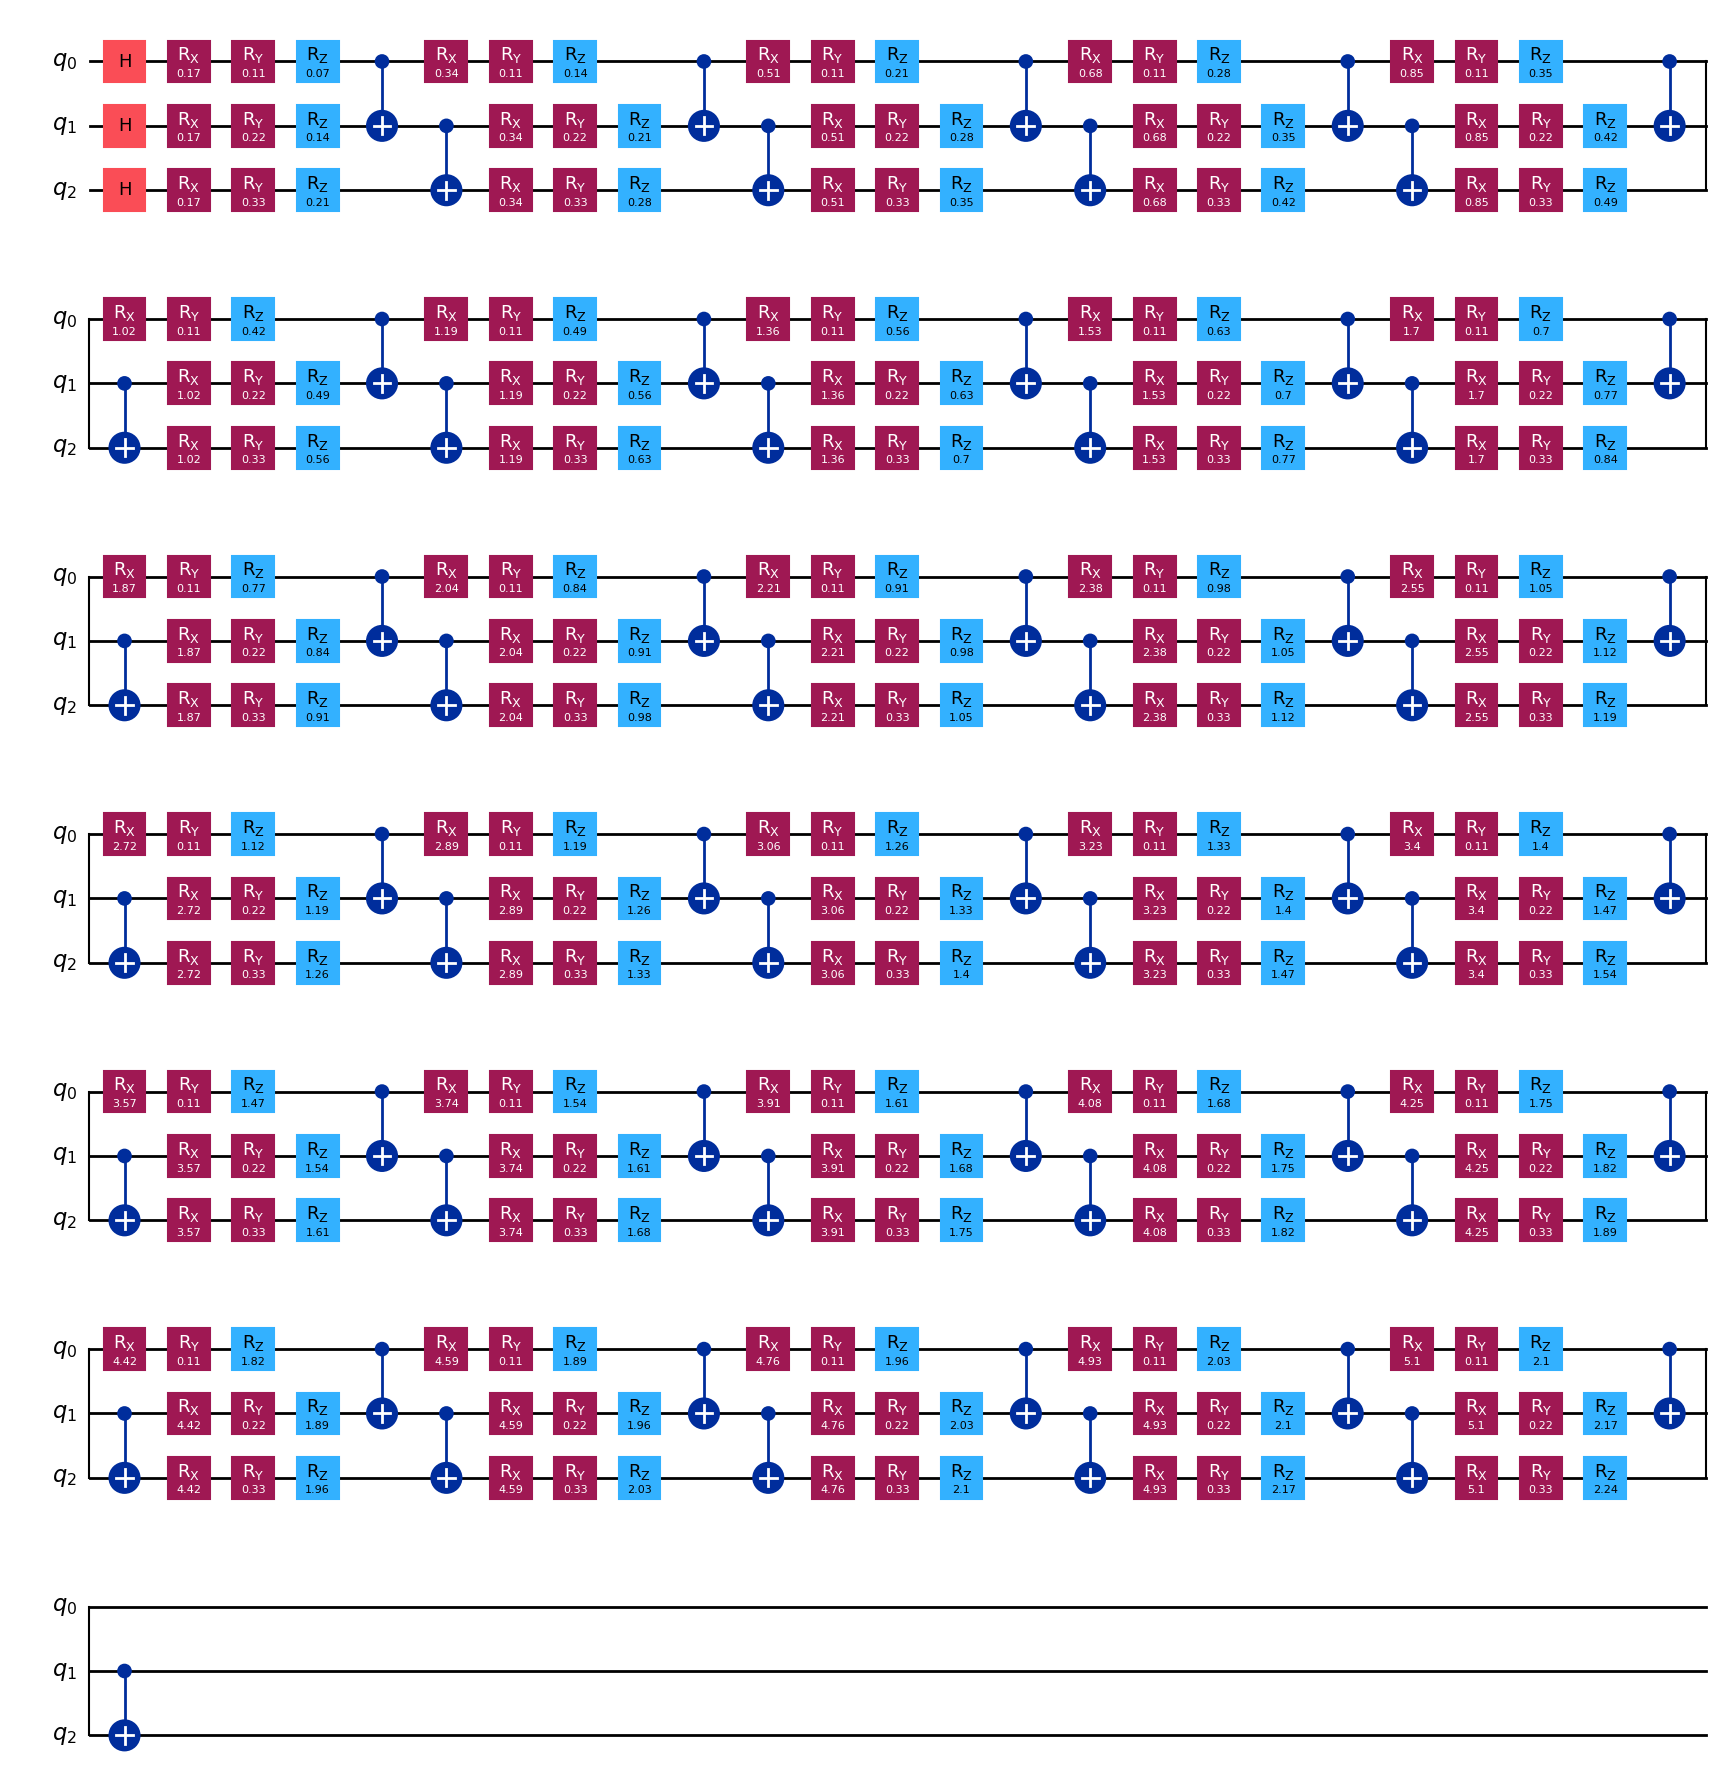

In [ ]:
qc.draw('mpl')

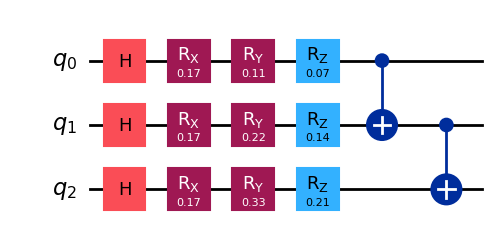

In [ ]:
qc_una_capa = crear_circuito(n_qubits=3, capas=1)

qc_una_capa.draw('mpl')